# Hasil eksekusi Colab: 13_uji_kombinasi_atribut

Dijalankan di VM Colab GPU T4 (sesi `ml13`). Sel di bawah adalah kode notebook asli beserta outputnya.


In [ ]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, precision_recall_curve,
                             roc_auc_score)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
SEED = 42

URL_BERSIH = ("https://raw.githubusercontent.com/ravi-arnan/machine-learning/"
              "main/artifacts/stroke_bersih.csv")
try:
    df = pd.read_csv(URL_BERSIH)
except Exception:
    df = pd.read_csv("../artifacts/stroke_bersih.csv")

y = df["stroke"].astype(int)
X_dasar = pd.get_dummies(df.drop(columns=["stroke"]), drop_first=True).astype(float)

print("Ukuran data bersih   :", df.shape)
print(f"Kasus stroke         : {int(y.sum())} ({y.mean()*100:.2f}%)")
print(f"Fitur dasar (one-hot): {X_dasar.shape[1]}")
df.head(3)

Ukuran data bersih   : (5109, 11)
Kasus stroke         : 249 (4.87%)
Fitur dasar (one-hot): 15


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.60000,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,31.84859,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.50000,never smoked,1


In [ ]:
def fitur_turunan(d):
    """Fitur turunan if-else, disalin dari laporan Pertemuan 3. Nilainya ordinal:
    semakin besar semakin berisiko."""
    f = pd.DataFrame(index=d.index)
    f["glukosa_kat"] = np.digitize(d["avg_glucose_level"], [100, 140, 200]).astype(float)
    f["bmi_kat"] = np.digitize(d["bmi"], [18.5, 25, 30]).astype(float)
    f["jumlah_faktor"] = (d["hypertension"] + d["heart_disease"]
                          + (d["avg_glucose_level"] > 200).astype(int)
                          + (d["bmi"] >= 30).astype(int)
                          + (d["age"] >= 60).astype(int)).astype(float)
    f["risiko_nested"] = 0.0
    f.loc[(d.hypertension == 1) | (d.heart_disease == 1), "risiko_nested"] = 1
    f.loc[(d.hypertension == 1) & (d.heart_disease == 1), "risiko_nested"] = 2
    f.loc[(d.hypertension == 1) & (d.heart_disease == 1)
          & (d.avg_glucose_level > 200), "risiko_nested"] = 3
    f.loc[(d.hypertension == 1) & (d.heart_disease == 1)
          & (d.avg_glucose_level > 200) & (d.age > 60), "risiko_nested"] = 4
    return f


TURUNAN = ["glukosa_kat", "bmi_kat", "jumlah_faktor", "risiko_nested"]
X = pd.concat([X_dasar, fitur_turunan(df)], axis=1)

print("Fitur dasar   :", X_dasar.shape[1])
print("Fitur turunan :", len(TURUNAN))
print("Total fitur   :", X.shape[1])

Fitur dasar   : 15
Fitur turunan : 4
Total fitur   : 19


In [ ]:
GRUP = {
    "usia (age)": ["age"],
    "hipertensi": ["hypertension"],
    "penyakit jantung": ["heart_disease"],
    "glukosa": ["avg_glucose_level"],
    "bmi": ["bmi"],
    "jenis kelamin": ["gender"],
    "status menikah": ["ever_married"],
    "pekerjaan": ["work_type"],
    "wilayah": ["Residence_type"],
    "merokok": ["smoking_status"],
}
KLINIS = ["usia (age)", "hipertensi", "penyakit jantung", "glukosa"]
SOSIAL = ["jenis kelamin", "status menikah", "pekerjaan", "wilayah", "merokok"]


def kolom(grup):
    """Ubah nama kelompok jadi daftar kolom.

    Kolom dasar dicocokkan ke kolom one-hot: 'gender' cocok dengan 'gender_Male'.
    Turunan if-else ditambahkan apa adanya. dict.fromkeys membuang kolom kembar
    kalau sebuah kombinasi memuat kelompok yang bertumpang.
    """
    kol = []
    for g in grup:
        if g == "turunan if-else":
            kol += TURUNAN
        else:
            for k in GRUP[g]:
                kol += [c for c in X_dasar.columns if c == k or c.startswith(k + "_")]
    return list(dict.fromkeys(kol))

In [ ]:
KOMBINASI = {
    "A. Usia saja": ["usia (age)"],
    "B. Usia + glukosa": ["usia (age)", "glukosa"],
    "C. Usia + glukosa + hipertensi + bmi": ["usia (age)", "glukosa", "hipertensi", "bmi"],
    "D. Usia + hipertensi + penyakit jantung": ["usia (age)", "hipertensi", "penyakit jantung"],
    "E. Inti klinis": KLINIS,
    "F. Inti klinis + bmi": KLINIS + ["bmi"],
    "G. Semua fitur dasar": KLINIS + ["bmi"] + SOSIAL,
    "H. Semua fitur + turunan if-else": KLINIS + ["bmi"] + SOSIAL + ["turunan if-else"],
}

ringkas = pd.DataFrame(
    [{"Kombinasi": nama, "jumlah fitur": len(kolom(grup))} for nama, grup in KOMBINASI.items()]
)
ringkas

,Kombinasi,jumlah fitur
0,A. Usia saja,1
1,B. Usia + glukosa,2
2,C. Usia + glukosa + hipertensi + bmi,4
3,D. Usia + hipertensi + penyakit jantung,3
4,E. Inti klinis,4
5,F. Inti klinis + bmi,5
6,G. Semua fitur dasar,15
7,H. Semua fitur + turunan if-else,19


In [ ]:
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)


def model_acuan():
    """Logistic Regression dengan hyperparameter hasil GridSearch notebook 07."""
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(C=0.1, penalty="l1", solver="liblinear",
                           max_iter=5000, random_state=SEED),
    )


def skor_oof(model, Xk, y, cv=cv):
    """Probabilitas out-of-fold kelas stroke."""
    return cross_val_predict(model, Xk, y, cv=cv, method="predict_proba")[:, 1]


def presisi_pada_recall(y_true, p, target=0.80):
    """Precision terbesar yang masih mencapai recall >= target."""
    pres, rec, _ = precision_recall_curve(y_true, p)
    idx = np.where(rec >= target)[0]
    return float(pres[idx].max()) if len(idx) else float("nan")


def bootstrap_ap(y_true, p, B=2000, seed=SEED):
    """Selang kepercayaan 95% untuk average precision."""
    rng = np.random.default_rng(seed)
    yt = np.asarray(y_true)
    n = len(yt)
    nilai = []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        if yt[idx].sum() == 0:
            continue
        nilai.append(average_precision_score(yt[idx], p[idx]))
    return float(np.percentile(nilai, 2.5)), float(np.percentile(nilai, 97.5))

In [ ]:
baris = []
for nama, grup in KOMBINASI.items():
    kol = kolom(grup)
    p = skor_oof(model_acuan(), X[kol], y)
    ap = average_precision_score(y, p)
    lo, hi = bootstrap_ap(y, p)
    baris.append({
        "Kombinasi atribut": nama,
        "jumlah fitur": len(kol),
        "AP": round(ap, 4),
        "AP 2,5%": round(lo, 4),
        "AP 97,5%": round(hi, 4),
        "precision @ recall 0,80": round(presisi_pada_recall(y, p), 4),
        "ROC-AUC": round(roc_auc_score(y, p), 4),
    })

tabel = pd.DataFrame(baris).sort_values("AP", ascending=False).reset_index(drop=True)
tabel

,Kombinasi atribut,jumlah fitur,AP,"AP 2,5%","AP 97,5%","precision @ recall 0,80",ROC-AUC
0,F. Inti klinis + bmi,5,0.1839,0.1545,0.2237,0.1316,0.8409
1,E. Inti klinis,4,0.1839,0.1545,0.2237,0.1316,0.8409
2,G. Semua fitur dasar,15,0.1830,0.1541,0.2249,0.1317,0.8398
3,C. Usia + glukosa + hipertensi + bmi,4,0.1828,0.1535,0.2237,0.1317,0.8406
4,B. Usia + glukosa,2,0.1811,0.1519,0.2219,0.1336,0.8392
5,H. Semua fitur + turunan if-else,19,0.1792,0.1517,0.2189,0.1303,0.8394
6,D. Usia + hipertensi + penyakit jantung,3,0.1768,0.1478,0.2179,0.1271,0.8371
7,A. Usia saja,1,0.1644,0.1390,0.1964,0.1279,0.8334


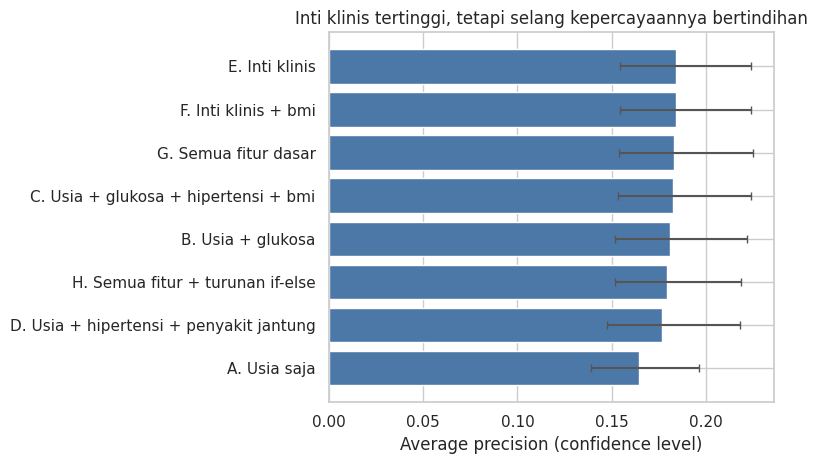

In [ ]:
urut_ap = tabel.sort_values("AP")
galat = np.array([urut_ap["AP"] - urut_ap["AP 2,5%"],
                  urut_ap["AP 97,5%"] - urut_ap["AP"]])

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(urut_ap["Kombinasi atribut"], urut_ap["AP"], xerr=galat,
        color="#4C78A8", error_kw={"ecolor": "#555", "capsize": 3})
ax.set_xlabel("Average precision (confidence level)")
ax.set_title("Inti klinis tertinggi, tetapi selang kepercayaannya bertindihan")
plt.tight_layout()
plt.show()

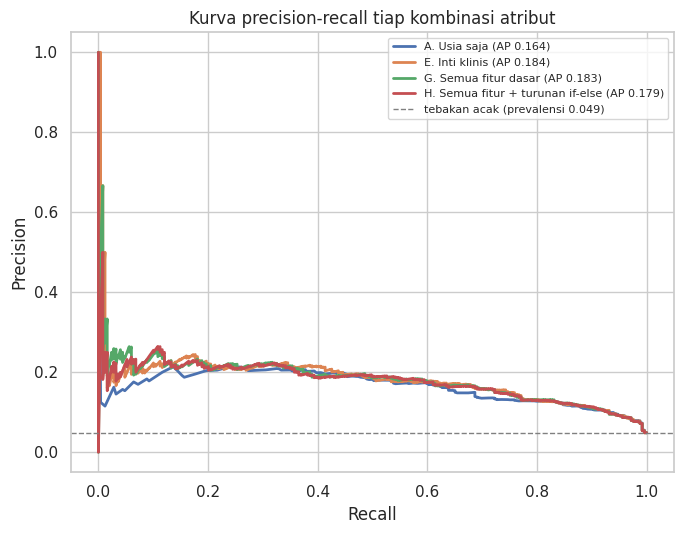

In [ ]:
kombinasi_diplot = ["A. Usia saja", "E. Inti klinis", "G. Semua fitur dasar",
         "H. Semua fitur + turunan if-else"]

fig, ax = plt.subplots(figsize=(7, 5.5))
for nama in kombinasi_diplot:
    p = skor_oof(model_acuan(), X[kolom(KOMBINASI[nama])], y)
    pres, rec, _ = precision_recall_curve(y, p)
    ax.plot(rec, pres, lw=2,
            label=f"{nama} (AP {average_precision_score(y, p):.3f})")
ax.axhline(y.mean(), color="grey", ls="--", lw=1,
           label=f"tebakan acak (prevalensi {y.mean():.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Kurva precision-recall tiap kombinasi atribut")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
GROUPS = list(GRUP.keys())
ap_penuh = average_precision_score(y, skor_oof(model_acuan(), X[kolom(GROUPS)], y))

abl = [{"dibuang": "(tidak ada)", "AP": round(ap_penuh, 4), "selisih AP": 0.0}]
for g in GROUPS:
    p = skor_oof(model_acuan(), X[kolom([x for x in GROUPS if x != g])], y)
    ap_tanpa = average_precision_score(y, p)
    abl.append({"dibuang": g, "AP": round(ap_tanpa, 4), "selisih AP": round(ap_tanpa - ap_penuh, 4)})

abl = pd.DataFrame(abl)
print(f"AP semua fitur dasar: {ap_penuh:.4f}\n")
abl

AP semua fitur dasar: 0.1830



,dibuang,AP,selisih AP
0,(tidak ada),0.1830,0.0000
1,usia (age),0.1251,-0.0579
2,hipertensi,0.1832,0.0002
3,penyakit jantung,0.1845,0.0015
4,glukosa,0.1774,-0.0056
5,bmi,0.1830,-0.0000
6,jenis kelamin,0.1841,0.0011
7,status menikah,0.1876,0.0046
8,pekerjaan,0.1788,-0.0042
9,wilayah,0.1832,0.0002


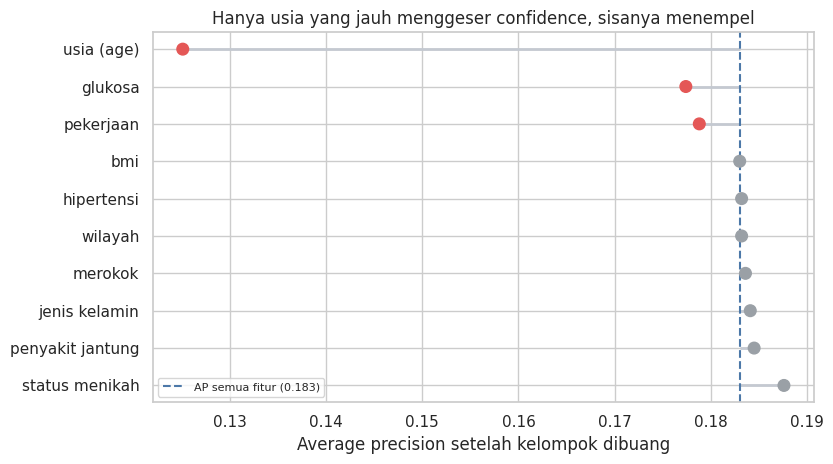

In [ ]:
ap_penuh = abl.loc[abl["dibuang"] == "(tidak ada)", "AP"].iloc[0]
urut = abl[abl["dibuang"] != "(tidak ada)"].copy().sort_values("AP")
warna = ["#E45756" if v < ap_penuh else "#9AA0A6" for v in urut["AP"]]

# Grafik titik: titik jauh dari garis putus-putus berarti kelompok itu benar-benar
# menggeser confidence. Sumbu-x memakai AP absolut supaya beda kecil tetap terlihat.
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.hlines(urut["dibuang"], urut["AP"], ap_penuh, color="#C4C9D1", lw=2)
ax.scatter(urut["AP"], urut["dibuang"], c=warna, s=70, zorder=3)
ax.axvline(ap_penuh, color="#4C78A8", ls="--", lw=1.5,
           label=f"AP semua fitur ({ap_penuh:.3f})")
ax.set_xlabel("Average precision setelah kelompok dibuang")
ax.set_title("Hanya usia yang jauh menggeser confidence, sisanya menempel")
ax.legend(loc="lower left", fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
terpilih, sisa, riwayat = [], list(GRUP.keys()), []
while sisa:
    kandidat = []
    for g in sisa:
        p = skor_oof(model_acuan(), X[kolom(terpilih + [g])], y)
        kandidat.append((average_precision_score(y, p), g))
    ap_terbaik, grup_terbaik = max(kandidat)
    terpilih.append(grup_terbaik)
    sisa.remove(grup_terbaik)
    riwayat.append({"ditambahkan": grup_terbaik, "AP": round(ap_terbaik, 4)})

pd.DataFrame(riwayat)

,ditambahkan,AP
0,usia (age),0.1644
1,glukosa,0.1811
2,pekerjaan,0.1886
3,bmi,0.1886
4,wilayah,0.1885
5,merokok,0.1885
6,hipertensi,0.1878
7,penyakit jantung,0.1885
8,jenis kelamin,0.1876
9,status menikah,0.1830


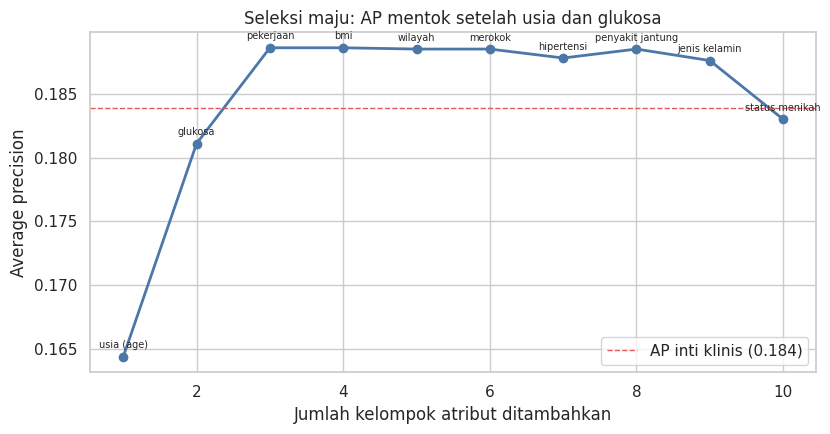

In [ ]:
urutan = pd.DataFrame(riwayat)
ap_klinis = average_precision_score(
    y, skor_oof(model_acuan(), X[kolom(KOMBINASI["E. Inti klinis"])], y))

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(range(1, len(urutan) + 1), urutan["AP"], "o-", color="#4C78A8", lw=2)
for i, r in urutan.iterrows():
    ax.annotate(r["ditambahkan"], (i + 1, r["AP"]), fontsize=7,
                xytext=(0, 6), textcoords="offset points", ha="center")
ax.axhline(ap_klinis, color="#E45756", ls="--", lw=1,
           label=f"AP inti klinis ({ap_klinis:.3f})")
ax.set_xlabel("Jumlah kelompok atribut ditambahkan")
ax.set_ylabel("Average precision")
ax.set_title("Seleksi maju: AP mentok setelah usia dan glukosa")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
MODEL = {
    "Logistic Regression": model_acuan(),
    "Gradient Boosting": make_pipeline(
        StandardScaler(), GradientBoostingClassifier(random_state=SEED)),
    "KNN (k=15)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)),
    "Gaussian Naive Bayes": make_pipeline(StandardScaler(), GaussianNB()),
}

uji = ["E. Inti klinis", "G. Semua fitur dasar", "H. Semua fitur + turunan if-else"]
baris = []
for nama_model, m in MODEL.items():
    for nama_kombinasi in uji:
        p = skor_oof(m, X[kolom(KOMBINASI[nama_kombinasi])], y)
        baris.append({
            "Model": nama_model,
            "Kombinasi atribut": nama_kombinasi,
            "AP": round(average_precision_score(y, p), 4),
            "precision @ recall 0,80": round(presisi_pada_recall(y, p), 4),
            "ROC-AUC": round(roc_auc_score(y, p), 4),
        })

lintas = pd.DataFrame(baris)
lintas.pivot(index="Kombinasi atribut", columns="Model", values="AP")

Model,Gaussian Naive Bayes,Gradient Boosting,KNN (k=15),Logistic Regression
Kombinasi atribut,,,,
E. Inti klinis,0.1659,0.1521,0.1176,0.1839
G. Semua fitur dasar,0.1520,0.1554,0.1005,0.1830
H. Semua fitur + turunan if-else,0.1483,0.1578,0.0997,0.1792
